In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


Columns Description

comment : The raw text content of the comment.

created_date : The date and time when the comment was posted.

post_id : A unique identifier linking the comment to a discussion thread or parent post.

emoticon_1 : Indicator for the presence of symbols from the first internal emoticon group.

emoticon_2 : Indicator for the presence of symbols from the second internal emoticon group.

emoticon_3 : Indicator for the presence of symbols from the third internal emoticon group.

upvote : Number of positive reactions received by the comment.

downvote : Number of negative reactions received by the comment.

if_1 : Internal feature one that is hidden by the platform.

if_2 : Internal feature two that is hidden by the platform.

race : Indicator showing whether the system detected references to a specific group identity.

religion : Indicator showing whether the system detected references to a belief-related topic.

gender : Indicator showing whether the system detected references to a gender-related topic.

disability : Indicator showing whether the system detected references to an ability-related topic.

label : The final category assigned to the comment by the platform (Target Variable). This variable can take four distinct values, each corresponding to a different internal handling category.

In [5]:

#Hypothesis Testing (T-Test)
from scipy.stats import ttest_ind

l0 = train_df[train_df['label'] == 0]['comment_length']
l1 = train_df[train_df['label'] == 1]['comment_length']

t_stat, p_val = ttest_ind(l0, l1, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_val)


t-statistic: -17.571943347613804
p-value: 1.2741273311606353e-68


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

from sklearn.decomposition import TruncatedSVD
from sklearn.feature_selection import SelectKBest, chi2

from sklearn.metrics import accuracy_score, classification_report

from scipy.sparse import hstack

In [3]:
#Data loading
import pandas as pd

import pandas as pd 
test= pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
sample = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

print(train.shape)
print(test.shape)
train.head()

(198000, 15)
(102000, 14)


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [5]:
train.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


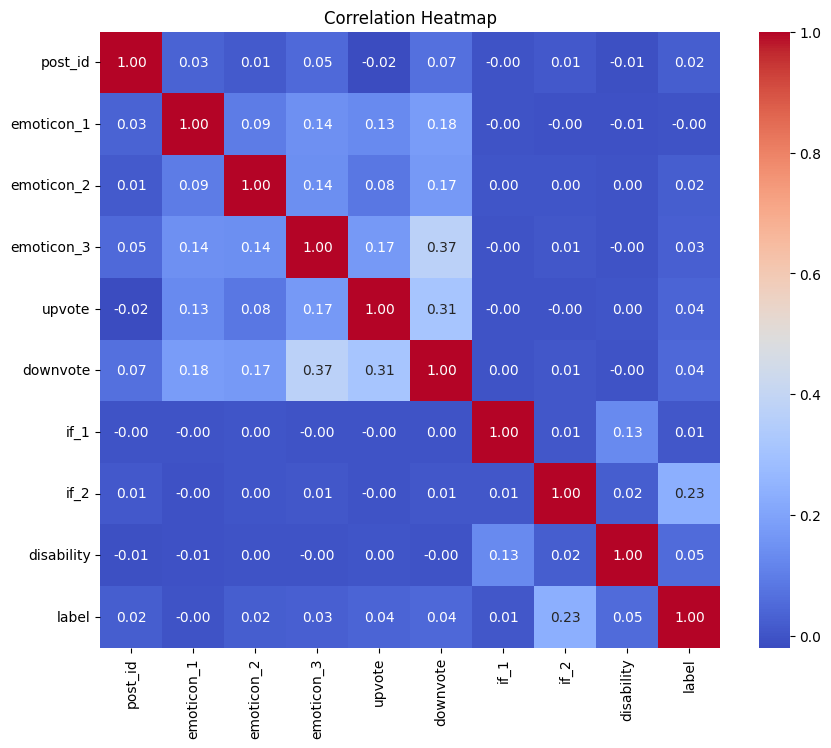

In [3]:
train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")

#correlation
'''A Correlation Matrix is a table that shows the correlation 
coefficients between multiple variables in a dataset. 
It helps us understand how strongly variables are related to each other.'''

#Imports required
import pandas as pd #Pandas is used for data handling and analysis.
import seaborn as sns #Seaborn is a data visualization library built on top of Matplotlib.
import matplotlib.pyplot as plt #Matplotlib is the core plotting library in Python.

# Convert boolean to int
train['disability'] = train['disability'].astype(int)

# Select only numeric columns
numeric_train= train.select_dtypes(include=['int64'])

# Compute correlation
corr_matrix = numeric_train.corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

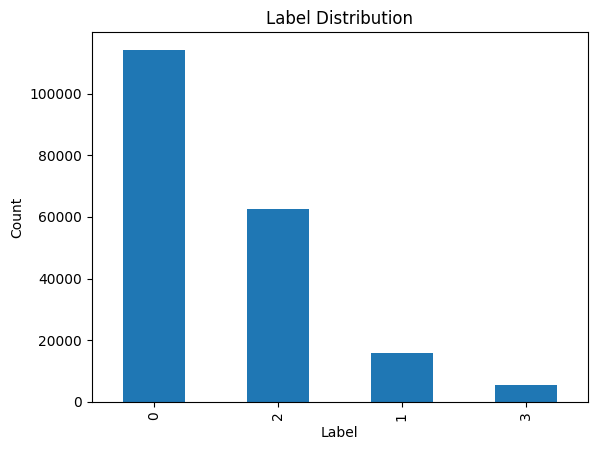

In [5]:
#Label Distribution Plot
import matplotlib.pyplot as plt

train_df['label'].value_counts().plot(kind='bar')
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


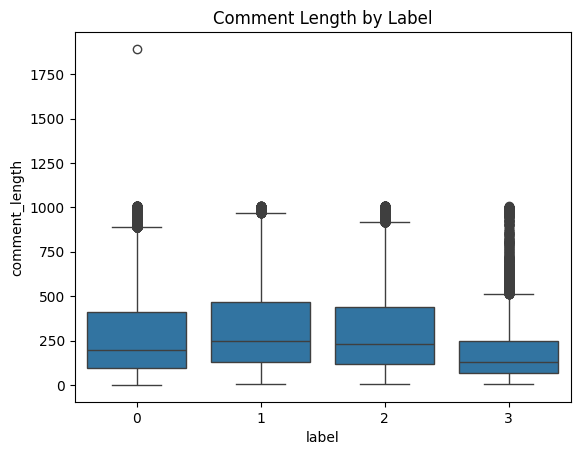

In [6]:
#Comment Length vs Label
import seaborn as sns

sns.boxplot(x='label', y='comment_length', data=train_df)
plt.title("Comment Length by Label")
plt.show() 

In [ ]:
# Check number of missing values in each column
missing_values = train.isnull().sum()
print(missing_values) 

Data Cleaning -
Data cleaning is the process of detecting, correcting, or handling missing, incomplete, or inconsistent data in a dataset. It improves the quality, reliability, and accuracy of data before applying machine learning or statistical analysis.

In machine learning projects, data cleaning is important because missing values, incorrect entries, or null fields can reduce model performance or cause errors during training.

In [4]:
# DATA CLEANING

# Fill missing text
#fillna("") replaces these missing values with an empty string.
train["comment"] = train["comment"].fillna("")
test["comment"] = test["comment"].fillna("")

# Fill categorical missing values
cat_cols = ["race", "religion", "gender"]
#Any missing value in these columns is replaced with "unknown".
for col in cat_cols:
    train[col] = train[col].fillna("unknown")
    test[col] = test[col].fillna("unknown")

Feature engineering is the process of creating, transforming, or selecting useful input variables (features) from raw data to improve the performance of machine learning models.
It helps the model better understand patterns in the data by converting raw information into meaningful numerical features.

In machine learning, many algorithms cannot directly process text, boolean, or categorical data, so feature engineering converts them into numerical formats that the model can use.

In [5]:
# FEATURE ENGINEERING

# Comment length
'''This creates a new column called comment_len.
It calculates the length of each comment.
Comment length can help the model understand patterns such as:
longer comments
shorter comments
possible correlation with the label (target variable).'''

train["comment_len"] = train["comment"].apply(len)
test["comment_len"] = test["comment"].apply(len)

# Convert boolean
'''The disability column contains True / False values.
Machine learning models require numeric input.
Converting to integers changes:
True to 1
False to 0'''

train["disability"] = train["disability"].astype(int)
test["disability"] = test["disability"].astype(int)

# Encode categorical variables
'''LabelEncoder converts categorical text values into numerical labels.'''
le = LabelEncoder()

for col in cat_cols:
    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])

Text vectorization is the process of converting textual data into numerical vectors so that machine learning models can process and analyze the text. Since ML algorithms cannot directly understand raw text, vectorization transforms words into numeric feature representations.
One commonly used technique is TF-IDF (Term Frequency–Inverse Document Frequency). TF-IDF measures how important a word is in a document relative to the entire dataset.

Term Frequency (TF): How frequently a word appears in a document.
Inverse Document Frequency (IDF): Reduces the importance of words that appear in many documents (like the, is, and).

In [6]:
# TEXT VECTORIZATION (TFIDF)

tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english"
)

X_text = tfidf.fit_transform(train["comment"])
X_test_text = tfidf.transform(test["comment"])

In [7]:
# NUMERIC FEATURES
num_cols = [
    "emoticon_1","emoticon_2","emoticon_3",
    "upvote","downvote","if_1","if_2",
    "race","religion","gender",
    "disability","comment_len"
]

# Extract numeric features from training dataset
X_num = train[num_cols]

# Extract numeric features from test dataset
X_test_num = test[num_cols]

# hstack horizontally stacks the sparse TF-IDF matrix with numeric features
# This creates a single feature matrix containing both textual and numeric data

# Combine text + numeric
X = hstack([X_text, X_num])
X_test = hstack([X_test_text, X_test_num])

y = train["label"]


In [8]:
#TRAIN VALIDATION SPLIT

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
) 

Linear Regression: Predicts continuous numeric values, such as prices, temperature, or sales figures. 

Logistic Regression: Predicts the probability of a categorical outcome, such as spam/not-spam or disease/healthy

Logistic Regression-
Logistic Regression is a supervised machine learning algorithm used for classification problems that predicts the probability of a data point belonging to a particular class.

Paramters - 
penalty	'l2'-Type of regularization
C	1.0	-Inverse of regularization strength
solver	'lbfgs'	-Optimization algorithm (lbfgs (default, fast),liblinear,saga
max_iter	100	-Maximum number of iterations
fit_intercept	True	-Whether to include intercept
class_weight	None	-Handles class imbalance
random_state	None	-Controls randomness
multi_class	'auto'	-Strategy for multiclass problems

In [16]:
# BASELINE MODEL

log_model = LogisticRegression(max_iter=1000) #update itself up to 1000 times

log_model.fit(X_train, y_train)

pred = log_model.predict(X_val)

print("Logistic Regression Accuracy:", accuracy_score(y_val, pred))


Logistic Regression Accuracy: 0.8634848484848485


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

pred = model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, pred))

# Train on full data
model.fit(X, y)

test_pred = model.predict(X_test)

submission = pd.DataFrame({
    "ID": test.index,
    "label": test_pred
})

submission.to_csv("submission_logistic.csv", index=False)
print("Logistic submission created")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.8634848484848485
Logistic submission created


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [19]:
from IPython.display import FileLink
FileLink("submission_logistic.csv") 

/kaggle/working/submission_logistic.csv

In [15]:
# hypertuning on logistic Regression
from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],#Regularization strength (inverse of penalty)
    'penalty': ['l2'],#Type of regularization
    'solver': ['lbfgs'] #Algorithm used to train the model
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid_lr,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print("Best Parameters:", grid_lr.best_params_)
best_lr = grid_lr.best_estimator_
y_pred_best_lr = best_lr.predict(X_val)

print(classification_report(y_val, y_pred_best_lr))

Best Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     22835
           1       0.79      0.70      0.74      3183
           2       0.84      0.91      0.87     12488
           3       0.72      0.45      0.55      1094

    accuracy                           0.90     39600
   macro avg       0.83      0.75      0.78     39600
weighted avg       0.90      0.90      0.90     39600



In [4]:
# IMPORTS
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion

# TEXT TFIDF (OPTIMAL SIZE)
word_tfidf = TfidfVectorizer(
    max_features=90000,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.9,
    sublinear_tf=True
)

char_tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3,5),
    max_features=30000
)

text_features = FeatureUnion([
    ("word", word_tfidf),
    ("char", char_tfidf)
])

# PREPROCESSOR
preprocessor = ColumnTransformer([
    ("text", text_features, text_col),
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

# MODEL 
model = LogisticRegression(
    C=5,
    max_iter=5000,
    class_weight="balanced",
    n_jobs=-1
)

pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", model)
])

# TRAIN
pipeline.fit(X, y)

# PREDICT
test_pred = pipeline.predict(X_test)

sample["label"] = test_pred
sample.to_csv("submission.csv", index=False)

print("submission.csv created")


submission.csv created


In [11]:
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
# ================================
# TRAIN VALIDATION SPLIT
# ================================
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

model_pipeline.fit(X_train, y_train)
val_pred = model_pipeline.predict(X_val)
print("\nClassification Report:\n")
print(classification_report(y_val, val_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.93      0.95     22835
           1       0.69      0.81      0.75      3183
           2       0.87      0.89      0.88     12488
           3       0.59      0.70      0.64      1094

    accuracy                           0.90     39600
   macro avg       0.78      0.83      0.80     39600
weighted avg       0.90      0.90      0.90     39600



In [10]:
from IPython.display import FileLink
FileLink("submission.csv") 

/kaggle/working/submission.csv

In [14]:

#SGDClassifier
from sklearn.linear_model import SGDClassifier

sgd_model = SGDClassifier(
    loss='log_loss',     # logistic regression
    max_iter=1000,
    random_state=42
)

sgd_model.fit(X_train_final, y_train)


y_pred_sgd = sgd_model.predict(X_val_final)
from sklearn.metrics import accuracy_score

sgd_accuracy = accuracy_score(y_val, y_pred_sgd)
print("SGD Model Accuracy:", sgd_accuracy)
print(classification_report(y_val, y_pred_sgd))


SGD Model Accuracy: 0.8807323232323232
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     22835
           1       0.83      0.49      0.62      3183
           2       0.76      0.92      0.84     12488
           3       0.89      0.08      0.15      1094

    accuracy                           0.88     39600
   macro avg       0.86      0.61      0.64     39600
weighted avg       0.89      0.88      0.87     39600



SGDClassifier-
SGDClassifier is a machine learning classifier in scikit-learn that uses Stochastic Gradient Descent (SGD) to train linear models efficiently, especially for large-scale and high-dimensional data.


w = n (td-od)x
w = weight 
t = target 
o calculated value
x datapoint

This defines all combinations to try:

loss:

'log_loss' → Logistic Regression

'hinge' → SVM (Support Vector Machine)

alpha:

Regularization strength (smaller = less penalty)

penalty:

'l1' → feature selection (sparse)

'l2' → smooth regularization

SGDClassifier(...)

Model trained using Stochastic Gradient Descent

param_grid_sgd

All parameter combinations to test

cv=3

Uses 3-fold cross-validation

Data is split into 3 parts:

Train on 2 parts

Test on 1 part (repeat 3 times)

scoring='f1_macro'

Evaluates model using F1-score (macro average)

Good for imbalanced datasets

n_jobs=-1

Uses all CPU cores → faster training

In [21]:
# STOCHASTIC GRADIENT DESCENT 
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

model = SGDClassifier(loss="log_loss")

model.fit(X_train, y_train)

pred = model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, pred))

model.fit(X, y)

test_pred = model.predict(X_test)

submission = pd.DataFrame({
    "ID": test.index,
    "label": test_pred
})

submission.to_csv("submission_sgd.csv", index=False)
print("SGD submission created")

Accuracy: 0.7916414141414141
SGD submission created


In [22]:
from IPython.display import FileLink
FileLink("submission_sgd.csv") 

/kaggle/working/submission_sgd.csv

In [18]:
#SGD Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report
param_grid_sgd = {
    'loss': ['log_loss', 'hinge'],
    'alpha': [1e-4, 1e-3, 1e-2],
    'penalty': ['l2', 'l1']
}

grid_sgd = GridSearchCV(
    SGDClassifier(max_iter=1000, random_state=42),
    param_grid_sgd,
    cv=3,
    scoring='f1_macro', # precision and recall 
    n_jobs=-1
) 

grid_sgd.fit(X_train, y_train)

print("Best Parameters:", grid_sgd.best_params_)
best_sgd = grid_sgd.best_estimator_
y_pred_best_sgd = best_sgd.predict(X_val)

print(classification_report(y_val, y_pred_best_sgd))


Best Parameters: {'alpha': 0.0001, 'loss': 'hinge', 'penalty': 'l1'}
              precision    recall  f1-score   support

           0       0.97      0.94      0.96     22835
           1       0.79      0.64      0.71      3183
           2       0.80      0.92      0.86     12488
           3       0.68      0.26      0.37      1094

    accuracy                           0.89     39600
   macro avg       0.81      0.69      0.72     39600
weighted avg       0.90      0.89      0.89     39600



Naive Bayes - 
Naive Bayes is a supervised machine learning algorithm used for classification that is based on Bayes’ Theorem and assumes that all features are independent of each other.

p(y|x) = p(x|y) p(y) / p(x)

Parameters -
alpha - If a word never appears in training → probability becomes 0
    alpha fixes this by adding a small value
fit_prior-Whether to learn class probabilities from data
    True → learn from dataset (default)
    False → assume all classes are equal
class_prior-Manually set class probabilities
var_smoothing-Helps avoid division by zero,Stabilizes variance calculations

In [21]:
#Naive Bayes
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_text, y_train)
y_pred_nb = nb_model.predict(X_val_text)

print("Naive Bayes")
print(classification_report(y_val, y_pred_nb))

Naive Bayes
              precision    recall  f1-score   support

           0       0.70      0.93      0.80     22835
           1       0.73      0.36      0.48      3183
           2       0.78      0.47      0.59     12488
           3       0.81      0.05      0.10      1094

    accuracy                           0.72     39600
   macro avg       0.75      0.45      0.49     39600
weighted avg       0.73      0.72      0.69     39600



In [22]:
# Train Naive Bayes 
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_text, y_train)


# Preprocess Test Text 
test_df['comment'] = test_df['comment'].fillna("")

# TFIDF Transform
X_test_text = tfidf.transform(test_df['comment'])


#  Predict
test_pred_nb = nb.predict(X_test_text)


sample['label'] = test_pred_nb
sample.to_csv("submission_nb.csv", index=False)

print("submission_nb.csv created ")


submission_nb.csv created 


In [23]:
from IPython.display import FileLink
FileLink("submission_nb.csv") 

/kaggle/working/submission_nb.csv

KNN - 
K-Nearest Neighbors (KNN) is a supervised machine learning algorithm used for classification and regression that works by finding the k closest data points (neighbors) to a given input and making predictions based on them.

Parameters - 
n_neighbors
weights-
    uniform → all neighbors have equal weight
    distance → closer neighbors have more influence
matrix -
    euclidean → straight-line distance (most used)
    manhattan → grid-based distance
    minkowski → general form (default)
    d(x,y)=(∑i=1to n ∣xi−yi∣p)1/p - 
x, 𝑦 - two data points
n → number of features
p → parameter that defines the type of distance
p - Controls distance calculation
    Values:
    p=1 → Manhattan distance 
    p=2 → Euclidean distance
algorithm - Method used to compute neighbors
    Options:
    auto (default)
    ball_tree
    kd_tree
    brute
n_jobs
    n_jobs=-1
    Uses all CPU cores for faster computation

In [27]:
#K NEAREST NEIGHBORS

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

pred = knn_model.predict(X_val)

print("KNN Accuracy:", accuracy_score(y_val, pred))

KNN Accuracy: 0.8429040404040404


In [34]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

# Fill missing comments
train_df['comment'] = train_df['comment'].fillna("")
test_df['comment'] = test_df['comment'].fillna("")

X_train_text = train_df['comment']
y_train = train_df['label']

X_test_text = test_df['comment']

knn_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('svd', TruncatedSVD(n_components=100, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

knn_pipeline.fit(X_train_text, y_train)

test_pred_knn = knn_pipeline.predict(X_test_text)

sample['label'] = test_pred_knn
sample.to_csv("submission_knn.csv", index=False)

print("submission_knn.csv created")

submission_knn.csv created


In [28]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

knn_model = KNeighborsClassifier(n_neighbors=5)

# Train
knn_model.fit(X_train_svd, y_train)

# Validation Prediction
y_pred_knn = knn_model.predict(X_val)

print("KNN")
print(classification_report(y_val, y_pred_knn))

KNN
              precision    recall  f1-score   support

           0       0.91      0.95      0.93     22835
           1       0.59      0.43      0.50      3183
           2       0.75      0.79      0.77     12488
           3       0.36      0.13      0.19      1094

    accuracy                           0.83     39600
   macro avg       0.65      0.57      0.60     39600
weighted avg       0.82      0.83      0.82     39600



In [35]:
from IPython.display import FileLink
FileLink("submission_knn.csv") 

/kaggle/working/submission_knn.csv

Support Vector Machine (SVM)  - 
Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification and regression that works by finding the optimal boundary (hyperplane) that best separates different classes of data.

Parameters -
C (Regularization Parameter)- Controls trade-off between margin size and classification error
    Small C → larger margin, allows some misclassification (bettergeneralization)
    Large C → smaller margin, tries to classify all points correctly (may overfit)
kernel - Defines how data is transformed
    linear → straight line (fast, good for text data)
    rbf (Radial Basis Function)→ nonlinear (most commonly used)
    poly → polynomial boundary
    sigmoid → neural-network-like
gamma (for RBF, Poly, Sigmoid) - Controls how far the influence of a data   point reaches (smaller the gamma smoother the line)
    Low gamma → smoother boundary
    High gamma → complex boundary (may overfit) 
degree (for polynomial kernel)
coef0 - 
    Used in poly and sigmoid
    Controls influence of higher-degree terms
class_weight - 
    SVC(class_weight='balanced')
    Handles imbalanced datasets
    Gives more importance to minority class

In [31]:
# SUPPORT VECTOR MACHINE

svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

pred = svm_model.predict(X_val)

print("SVM Accuracy:", accuracy_score(y_val, pred))

SVM Accuracy: 0.7953535353535354


In [32]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

model = LinearSVC()

model.fit(X_train, y_train)

pred = model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, pred))

model.fit(X, y)

test_pred = model.predict(X_test)

submission = pd.DataFrame({
    "ID": range(1, len(test_pred) + 1),
    "label": test_pred
})

submission.to_csv("submission_svm.csv", index=False)
print("SVM submission created")

Accuracy: 0.7953535353535354
SVM submission created


In [34]:
from IPython.display import FileLink
FileLink("submission_svm.csv") 

/kaggle/working/submission_svm.csv

Dimensionality reduction-
Dimensionality reduction is the process of reducing the number of input features (variables) in a dataset while preserving the most important information.

In [35]:
# DIMENSIONALITY REDUCTION
#Feature Extraction 
'''Truncated SVD creates new features by combining existing ones
It does not select original features, instead it transforms 
them into a new lower-dimensional space'''
#Svd is unsupervised,

#Singular Value Decomposition (SVD) 
#n_components=200 → reduces features to 200 dimensions
svd = TruncatedSVD(n_components=200)

X_train_svd = svd.fit_transform(X_train)
X_val_svd = svd.transform(X_val)

svd_model = LogisticRegression(max_iter=1000)

svd_model.fit(X_train_svd, y_train)

pred = svd_model.predict(X_val_svd)

print("SVD + Logistic Accuracy:", accuracy_score(y_val, pred))

SVD + Logistic Accuracy: 0.859040404040404


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Feature selection
Feature selection is the process of selecting the most important and relevant features from a dataset while removing unnecessary or irrelevant ones.

In [36]:
# FEATURE SELECTION
'''This code performs feature selection using Chi-Square 
and then trains a Logistic Regression model on the selected features.'''

selector = SelectKBest(chi2, k=5000)

X_train_fs = selector.fit_transform(X_train, y_train)
X_val_fs = selector.transform(X_val)

fs_model = LogisticRegression(max_iter=1000)

fs_model.fit(X_train_fs, y_train)

pred = fs_model.predict(X_val_fs)

print("Feature Selection Accuracy:", accuracy_score(y_val, pred))

Feature Selection Accuracy: 0.8598232323232323


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Bagging-
Bagging is an ensemble machine learning technique that improves model performance by training multiple models on different random subsets of the dataset and combining their predictions.
Advantages - 
Improves accuracy
Reduces overfitting
Stable and reliable
Disadvantages - 
Increased computational cost
Less interpretable

Paramters -
estimator base model
n_estimators - np of trees/models to train
max_samples - sample size
max_features - 
boothstrap-
Whether to use sampling with replacement
True -standard bagging
False - pasting (without replacement)
bootstrap_features=False
oob_score=True - out-of-bag samples to estimate accuracy

In [10]:
#Bagging 
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

model = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=10),
    n_estimators=20,
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_val)

print("Bagging Accuracy:", accuracy_score(y_val, pred))

# Train on full dataset
model.fit(X, y)

test_pred = model.predict(X_test)

submission = pd.DataFrame({
    "ID": range(1, len(test_pred)+1),
    "label": test_pred
})

submission.to_csv("submission_bagging.csv", index=False)

print("Bagging submission created")

Bagging Accuracy: 0.8889646464646465
Bagging submission created


In [11]:
from IPython.display import FileLink
FileLink("submission_bagging.csv") 

/kaggle/working/submission_bagging.csv

Boosting -
Boosting is an ensemble machine learning technique that builds models sequentially, where each new model focuses on correcting the errors made by previous models.
AdaBoost (Adaptive Boosting)
Gradient Boosting
XGBoost (advanced and widely used)
Reduces overfitting
Reduces variance
Improves accuracy

Parameters - 
Parameter	
estimator-	DecisionTreeClassifier(max_depth=1)	
Base model (weak learner, usually stump)
n_estimators-	50	-Number of models to train
learning_rate-	1.0	-Controls contribution of each model
algorithm-	'SAMME.R'	-Type of boosting algorithm

In [30]:
#Boosting (AdaBoost)
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_val)

print("AdaBoost Accuracy:", accuracy_score(y_val, pred))

# Train on full data
model.fit(X, y)

test_pred = model.predict(X_test)

submission = pd.DataFrame({
    "ID": range(1, len(test_pred) + 1),
    "label": test_pred
})

submission.to_csv("submission_adaboost.csv", index=False)

print("AdaBoost submission created")

AdaBoost Accuracy: 0.8705808080808081
AdaBoost submission created


In [31]:
from IPython.display import FileLink
FileLink("submission_adaboost.csv") 

/kaggle/working/submission_adaboost.csv

Stacking -
How It Works
Train multiple base models
Each model makes predictions
Use these predictions as new features
Train a meta-model on these features
Final prediction comes from the meta-model
Advantages - 
Often gives higher accuracy
Reduces model bias
Uses diverse models
Disadvantages - 
More complex
Higher computational cost
Risk of overfitting if not handled properly

In [ ]:
# STACKING ENSEMBLE 
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

estimators = [
    ("nb", MultinomialNB()),
    ("lr", LogisticRegression(max_iter=5000, solver="saga")),
    ("svm", LinearSVC()) #Linear SVM is a supervised machine learning algorithm for binary classification,
]

model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=5000, solver="saga"),# used to find the optimal parameters,SGD or SAGA 
    n_jobs=-1
)

model.fit(X_train, y_train)

pred = model.predict(X_val)

print("Stacking Accuracy:", accuracy_score(y_val, pred))

model.fit(X, y)

test_pred = model.predict(X_test)

submission = pd.DataFrame({
    "ID": range(1, len(test_pred) + 1),
    "label": test_pred
}) 

submission.to_csv("submission_stacking.csv", index=False)

print("Stacking submission created")         

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Stacking Accuracy: 0.9031565656565657


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
#Stacking Accuracy: 0.9031565656565657

In [33]:
from IPython.display import FileLink 
FileLink("submission_stacking.csv") 

/kaggle/working/submission_stacking.csv

In [ ]:
#Multi-Layer Perceptron (Neural Network)
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

model = MLPClassifier(
    hidden_layer_sizes=(128,64),
    max_iter=20,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_val)

print("MLP Accuracy:", accuracy_score(y_val, pred))

# Train on full data
model.fit(X, y)

test_pred = model.predict(X_test)

submission = pd.DataFrame({
    "ID": range(1, len(test_pred) + 1),
    "label": test_pred
})

submission.to_csv("submission_mlp.csv", index=False)

print("MLP submission created")            

#MLP Accuracy: 0.8868939393939393

In [15]:
# Classification Report
from sklearn.metrics import classification_report
print("\nClassification Report:\n") 
print(classification_report(y_val, pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.93      0.94     22534
           1       0.73      0.73      0.73      3219
           2       0.83      0.88      0.85     12738
           3       0.60      0.52      0.56      1109

    accuracy                           0.89     39600
   macro avg       0.78      0.76      0.77     39600
weighted avg       0.89      0.89      0.89     39600



In [16]:
from IPython.display import FileLink
FileLink("submission_mlp.csv") 

/kaggle/working/submission_mlp.csv

1. Model	Score
Logistic Regression	0.80 
AdaBoost	0.77
MLP (Neural Network)	0.776
Bagging (Decision Tree)	0.72
SVM	0.66
KNN	0.59
Naive Bayes	0.48


1. Logistic Regression (0.80 )
Performs best because:
Works extremely well with high-dimensional sparse data (TF-IDF)
Finds a linear decision boundary
Handles text classification efficiently

2. AdaBoost (0.77)
Strong performance because:
Focuses on misclassified samples
Improves weak learners (decision trees)
Slightly lower than LR because:
Decision trees are not ideal for sparse text data


4. MLP (0.776)
Neural network:
Captures complex patterns
Works well but:
Needs more tuning
Needs more data
Close to AdaBoost → good sign

4. Bagging (Decision Tree) (0.72)
Improves over single tree:
Reduces variance
More stable predictions
But:
Trees don’t handle high-dimensional TF-IDF well

5. SVM (0.66)
Normally strong for text, 
Likely using default or non-linear kernel
Text data works best with:
kernel='linear'

6. KNN (0.59)
Performs poorly because:
Uses distance-based learning
In high dimensions:
Distance becomes meaningless (curse of dimensionality)
Not suitable for TF-IDF data

7. Naive Bayes (0.48)
Expected behavior:
Assumes feature independence
TF-IDF features are often correlated

In [8]:

#Milestone 4
# =========================
# IMPORTS
# =========================
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, f1_score

from scipy.sparse import hstack


# =========================
# LOAD DATA
# =========================
df= pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")


# handle comment NaN
df["comment"] = df["comment"].fillna("")

X = df.drop("label", axis=1)
y = df["label"]


# =========================
# Q1 A : STRATIFIED SPLIT
# =========================
X_train_A, X_val_A, y_train_A, y_val_A = train_test_split(
    X, y,
    test_size=0.4,
    random_state=2306,
    stratify=y
)

train_counts_A = y_train_A.value_counts().sort_index().values
val_counts_A = y_val_A.value_counts().sort_index().values


# =========================
# Q1 B : NON STRATIFIED
# =========================
X_train_B, X_val_B, y_train_B, y_val_B = train_test_split(
    X, y,
    test_size=0.4,
    random_state=2306,
    stratify=None
)

train_counts_B = y_train_B.value_counts().sort_index().values
val_counts_B = y_val_B.value_counts().sort_index().values


# =========================
# Q1 C : MAX PROPORTION DIFF
# =========================
prop_A = val_counts_A / val_counts_A.sum()
prop_B = val_counts_B / val_counts_B.sum()

max_diff = np.max(np.abs(prop_A - prop_B))
print("Q1 Answer:", round(max_diff,4))


# =========================
# USE STRATIFIED SPLIT FOR REST
# =========================
x_train = X_train_A.copy()
x_test = X_val_A.copy()
y_train = y_train_A
y_test = y_val_A


# =========================
# STEP 1 : DROP COLUMN
# =========================
x_train = x_train.drop(columns=["created_date"])
x_test = x_test.drop(columns=["created_date"])


# =========================
# STEP 2 : SEPARATE TEXT
# =========================
text_x_train = x_train["comment"]
text_x_test = x_test["comment"]

x_train = x_train.drop(columns=["comment"])
x_test = x_test.drop(columns=["comment"])


# =========================
# STEP 3 : TABULAR PREPROCESS
# =========================
categorical_cols = ["race","religion","gender","disability"]

numeric_cols = [
"post_id","emoticon_1","emoticon_2","emoticon_3",
"upvote","downvote","if_1","if_2"
]


cat_pipe = Pipeline([
("imputer",SimpleImputer(strategy="most_frequent")),
("onehot",OneHotEncoder(handle_unknown="ignore",sparse_output=True))
])


num_pipe = Pipeline([
("imputer",SimpleImputer(strategy="mean")),
("scaler",StandardScaler())
])


preprocessor = ColumnTransformer([
("cat",cat_pipe,categorical_cols),
("num",num_pipe,numeric_cols)
], remainder="passthrough")


x_train_tabular = preprocessor.fit_transform(x_train)
x_test_tabular = preprocessor.transform(x_test)


# =========================
# STEP 4 : TEXT CLEANING
# =========================
def normalize_text(text):
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\s+', '  ', text).strip()
    return text


text_x_train_norm = text_x_train.apply(normalize_text)
text_x_test_norm = text_x_test.apply(normalize_text)


# =========================
# STEP 5 : TFIDF
# =========================
tfidf = TfidfVectorizer(stop_words="english", max_features=5000)

tf_idf_train = tfidf.fit_transform(text_x_train_norm)
tf_idf_test = tfidf.transform(text_x_test_norm)


# =========================
# STEP 6 : COMBINE FEATURES
# =========================
X_train_final = hstack([x_train_tabular, tf_idf_train])
X_test_final = hstack([x_test_tabular, tf_idf_test])

print("Q2 Answer:", round(X_train_final.sum(),3))


# =========================
# SVD DIMENSION REDUCTION
# =========================
svd = TruncatedSVD(n_components=300, random_state=2306)

X_train_reduced = svd.fit_transform(X_train_final)
X_test_reduced = svd.transform(X_test_final)


# =========================
# Q3 RANDOM FOREST TUNING
# =========================
rf = RandomForestClassifier(random_state=2306)

param_dist = {
"n_estimators":[50,100,200],
"max_depth":[5,10,15]
}

randomized_search = RandomizedSearchCV(
rf,
param_dist,
n_iter=5,
cv=3,
random_state=2306,
n_jobs=-1
)

randomized_search.fit(X_train_reduced,y_train)

print("Q3 Answer:", randomized_search.best_params_["n_estimators"])


# =========================
# Q4 ADABOOST
# =========================
ada = AdaBoostClassifier(
n_estimators=50,
random_state=2306
)

ada.fit(X_train_reduced,y_train)

var_errors = np.var(ada.estimator_errors_)

print("Q4 Answer:", round(var_errors,4))


# =========================
# Q5 RANDOM FOREST IMPORTANCE
# =========================
rf_model = RandomForestClassifier(
n_estimators=100,
max_depth=10,
random_state=2306
)

rf_model.fit(X_train_reduced,y_train)

importances = rf_model.feature_importances_

max_index = np.argmax(importances)

print("Q5 Answer:", max_index)


# =========================
# Q6 MLP WEIGHTS COUNT
# =========================
N = X_train_reduced.shape[1]

weights = (
N*128 +
128*64 +
64*32 +
32*4
)

print("Q6 Answer:", weights)


# =========================
# Q7 MLP TRAINING LOSS
# =========================
mlp = MLPClassifier(
hidden_layer_sizes=(128,64,32),
activation="relu",
solver="adam",
max_iter=5,
batch_size=32,
random_state=2306
)

mlp.fit(X_train_reduced,y_train)

print("Q7 Answer:", round(mlp.loss_,4))


# =========================
# Q8 MACRO F1 DIFFERENCE
# =========================
mlp_A = MLPClassifier(
hidden_layer_sizes=(100,),
max_iter=5,
random_state=2306,
alpha=0.0001
)

mlp_B = MLPClassifier(
hidden_layer_sizes=(100,),
max_iter=5,
random_state=2306,
alpha=1.0
)

mlp_A.fit(X_train_reduced,y_train)
mlp_B.fit(X_train_reduced,y_train)

pred_A = mlp_A.predict(X_train_reduced)
pred_B = mlp_B.predict(X_train_reduced)

f1_A = f1_score(y_train,pred_A,average="macro")
f1_B = f1_score(y_train,pred_B,average="macro")

print("Q8 Answer:", round(abs(f1_A - f1_B),4))


# =========================
# Q9 CONFUSION MATRIX ERROR RATE
# =========================
pred_val = mlp.predict(X_test_reduced)

cm = confusion_matrix(y_test,pred_val)

off_diag = cm.sum() - np.trace(cm)

error_rate = off_diag / cm.sum()

print("Q9 Answer:", round(error_rate,4)) 

Q1 Answer: 0.0006
Q2 Answer: 904262.933
Q3 Answer: 200
Q4 Answer: 0.0058
Q5 Answer: 4
Q6 Answer: 48768


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5) reached and the optimization hasn't converged yet.
  warnings.warn(


Q7 Answer: 0.3271


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5) reached and the optimization hasn't converged yet.
  warnings.warn(


Q8 Answer: 0.1327
Q9 Answer: 0.1126


In [3]:

#Milestone 5- 
test_df= pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
sample = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")
# ================================
# IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


# ================================
# STEP 1: TARGET EXTRACTION
# ================
y = df["label"]
df = df.drop("label", axis=1)


# ================================
# STEP 2: DATETIME FEATURE ENGINEERING
# ================================
df["created_date"] = pd.to_datetime(df["created_date"])
test_df["created_date"] = pd.to_datetime(test_df["created_date"])

for dataset in [df, test_df]:
    dataset["year"] = dataset["created_date"].dt.year
    dataset["month"] = dataset["created_date"].dt.month
    dataset["hour"] = dataset["created_date"].dt.hour
    dataset.drop("created_date", axis=1, inplace=True)


# ================================
# STEP 3: HANDLE MISSING VALUES
# ================================
for dataset in [df, test_df]:

    # categorical
    dataset["race"] = dataset["race"].fillna("Unknown")
    dataset["religion"] = dataset["religion"].fillna("Unknown")
    dataset["gender"] = dataset["gender"].fillna("Unknown")

    # text
    dataset["comment"] = dataset["comment"].fillna("")

    # boolean
    dataset["disability"] = dataset["disability"].astype(int)


# ================================
# STEP 4: COLUMN TRANSFORMER
# ================================
text_feature = "comment"

categorical_features = ["race","religion","gender"]

preprocessor = ColumnTransformer(

    transformers=[

        ("text",
         TfidfVectorizer(stop_words="english", max_features=5000),
         text_feature),

        ("cat",
         OneHotEncoder(drop="first", handle_unknown="ignore"),
         categorical_features)

    ],

    remainder="passthrough"
)


# ================================
# STEP 5: TRANSFORM DATA
# ================================
X = preprocessor.fit_transform(df)
X_test = preprocessor.transform(test_df)


# ================================
# STEP 6: TRAIN VALIDATION SPLIT
# ================================
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


# ================================
# Q1
# ================================
print("Q1:", 5000)


# ================================
# Q2
# ================================
print("Q2:", X_train.shape[1])


# ================================
# Q3
# ================================
print("Q3:", X_val.shape[1])


# ================================
# Q4: NAIVE BAYES
# ================================
nb = MultinomialNB()

nb.fit(X_train, y_train)

pred_nb = nb.predict(X_val)

nb_acc = accuracy_score(y_val, pred_nb)

print("Q4:", round(nb_acc,3))


# ================================
# Q5: PRECISION LABEL 3
# ================================
report_nb = classification_report(y_val, pred_nb, output_dict=True)

precision_label3 = report_nb["3"]["precision"]

print("Q5:", round(precision_label3,2))


# ================================
# Q6: LOGISTIC REGRESSION
# ================================
lr = LogisticRegression(max_iter=500, random_state=42)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_val)

lr_val_acc = accuracy_score(y_val, pred_lr)

print("Q6:", round(lr_val_acc,3))


# ================================
# Q7: TRAINING ACCURACY
# ================================
train_pred = lr.predict(X_train)

train_acc = accuracy_score(y_train, train_pred)

print("Q7:", round(train_acc,3))


# ================================
# Q8: PRECISION LABEL 1
# ================================
report_lr = classification_report(y_val, pred_lr, output_dict=True)

precision_label1 = report_lr["1"]["precision"]

print("Q8:", round(precision_label1,2))


# ================================
# Q9: GRID SEARCH
# ================================
param_grid = {

    "C":[0.1,1,10]

}

grid = GridSearchCV(
    LogisticRegression(max_iter=500, solver="liblinear"),
    param_grid,
    cv=3
)

grid.fit(X_train, y_train)

print("Q9:", grid.best_params_["C"])


# ================================
# Q10: VALIDATION ACCURACY
# ================================
best_model = grid.best_estimator_

pred_best = best_model.predict(X_val)

best_acc = accuracy_score(y_val, pred_best)

print("Q10:", round(best_acc,2)) 

Q1: 5000
Q2: 5031
Q3: 5031
Q4: 0.808
Q5: 0.52


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Q6: 0.839
Q7: 0.841
Q8: 0.62
Q9: 10
Q10: 0.87
